In [1]:
import librosa
import numpy as np
import torch
import cv2
import os

n_seconds=4
num_frames=8
#num_frames=16

#hop_length=49
#hop_length=24
#hop_length=16

# Datasetの__init__等で
hop_length = int((n_seconds * 22050) / (num_frames * 224)) 
# 約 49 になります。これなら4秒の音が1792ピクセルにピッタリ収まります。
print('hop_length:',hop_length)  # 8frames -> 49

# 1792 は、
# n_seconds * 22050 / hop_length
# 4 * 22050 / 49 = 1800


hop_length: 49


In [2]:
#%%writefile video_to_spectrogram_sequence.py
import numpy as np
import cv2
import librosa
#from moviepy.editor import VideoFileClip
from moviepy import VideoFileClip

def video_to_spectrogram_sequence(video_path, n_seconds=4, L_frames=8, hop_length=49):
    sr = 22050
    target_len = n_seconds * sr
    # 1. 音声の読み込み (MoviePyを使用)
    try:
        with VideoFileClip(video_path) as video:
            print(f"Sample rate: {video.audio.fps} Hz")
            # 指定秒数分を切り出し
            duration = min(video.duration, n_seconds)
            #audio_clip = video.audio.subclip(0, duration)
            # 修正後 (v2.0以降)
            audio_clip = video.audio.subclipped(0, duration)
            # 指定サンプリングレートでNumPy配列化
            y = audio_clip.to_soundarray(fps=sr)
            # ステレオ(2ch)なら平均をとってモノラル(1ch)に
            if len(y.shape) > 1:
                y = y.mean(axis=1)
            # 長さ調整（パディングまたはカット）
            if len(y) < target_len:
                y = np.pad(y, (0, target_len - len(y)))
            else:
                y = y[:target_len]
            audio_clip.close()
    except Exception as e:
        print(f"Audio extraction error: {e}")
        y = np.zeros(target_len)

    # add by nishi 2026.4.17
    # 音声を -1.0 〜 1.0 の範囲に正規化する
    if False:
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))
    # 2. メルスペクトログラムの計算
    # 黒パディングを消すために hop_length=49 を使用
    #hop_length = 49
    S = librosa.feature.melspectrogram(y=y.astype(np.float32), sr=sr, n_mels=224, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # 3. データの正規化 (-80dB〜0dB を 0〜255に)
    S_norm = ((S_dB + 80) / 80 * 255).clip(0, 255).astype(np.uint8)

    # 16枚で224幅を切り出すための計算 (1792 / 16 = 112)
    #if L_frames==8:
    #    step = 224
    #if L_frames==16:
    #    step = 112
    step=int(1792/ L_frames)
    print('step:',step)   # 8frames -> 224 , 16frames -> 112
        
    # 4. 時間軸方向にL_frames個の画像に分割
    # hop_length=49 なら total_width はほぼ 1792 (224*8) になります
    spectrogram_frames = []
    for i in range(L_frames):
        start = i * step
        end = start + 224
        frame = S_norm[:, start:end]
        
        # 端っこで幅が足りない場合はパディング
        if frame.shape[1] < 224:
            frame = np.pad(frame, ((0,0), (0, 224 - frame.shape[1])), mode='constant')
        # 1. RGB化 [H, W, C]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
        # 2. 【重要】正規化 (0-255 -> 0-1 & mean/std)
        # 後の可視化でエラーが出ないよう、ここで計算を済ませるのが安全です
        frame_float = frame_rgb.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        frame_normalized = (frame_float - mean) / std
        
        # 3. 【ここを修正】[H, W, C] -> [C, H, W] に変換
        frame_final = frame_normalized.transpose(2, 0, 1)
        spectrogram_frames.append(frame_final)
        
    return np.array(spectrogram_frames,dtype=np.float32) # 戻り値は [L, 3, 224, 224]

In [3]:
#%%writefile video_to_spectrogram_sequence.py
import numpy as np
import cv2
import librosa
#from moviepy.editor import VideoFileClip
from moviepy import VideoFileClip

def video_to_a_spectrogram(video_path, n_seconds=4, L_frames=8, hop_length=49):
    sr = 22050
    target_len = n_seconds * sr
    # 1. 音声の読み込み (MoviePyを使用)
    try:
        with VideoFileClip(video_path) as video:
            print(f"Sample rate: {video.audio.fps} Hz")
            # 指定秒数分を切り出し
            duration = min(video.duration, n_seconds)
            #audio_clip = video.audio.subclip(0, duration)
            # 修正後 (v2.0以降)
            audio_clip = video.audio.subclipped(0, duration)
            # 指定サンプリングレートでNumPy配列化
            y = audio_clip.to_soundarray(fps=sr)
            # ステレオ(2ch)なら平均をとってモノラル(1ch)に
            if len(y.shape) > 1:
                y = y.mean(axis=1)
            # 長さ調整（パディングまたはカット）
            if len(y) < target_len:
                y = np.pad(y, (0, target_len - len(y)))
            else:
                y = y[:target_len]
            audio_clip.close()
    except Exception as e:
        print(f"Audio extraction error: {e}")
        y = np.zeros(target_len)

    # add by nishi 2026.4.17
    # 音声を -1.0 〜 1.0 の範囲に正規化する
    if False:
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))
            
    # 2. メルスペクトログラムの計算
    # 黒パディングを消すために hop_length=49 を使用
    #hop_length = 49
    S = librosa.feature.melspectrogram(y=y.astype(np.float32), sr=sr, n_mels=224, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # 3. データの正規化 (-80dB〜0dB を 0〜255に)
    S_norm = ((S_dB + 80) / 80 * 255).clip(0, 255).astype(np.uint8)

    # 1. RGB化 [H, W, C]
    frame_rgb = cv2.cvtColor(S_norm, cv2.COLOR_GRAY2RGB)
    # 2. 【重要】正規化 (0-255 -> 0-1 & mean/std)
    # 後の可視化でエラーが出ないよう、ここで計算を済ませるのが安全です
    frame_float = frame_rgb.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    frame_normalized = (frame_float - mean) / std
    
    # 3. 【ここを修正】[H, W, C] -> [C, H, W] に変換
    frame_final = frame_normalized.transpose(2, 0, 1)
    return np.array(frame_final,dtype=np.float32) # 戻り値は [L, 3, 224, 224]

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def view_spectgram(anomaly_frames,total_frames,one_frame=False):
    print('anomaly_frames.shape:',anomaly_frames.shape)
    if one_frame:
        img_tensor = anomaly_frames
        # 3. 前処理(Normalize)を逆算して表示用に変換
        # 逆算しないと色が不自然に見えるため、平均と標準偏差を戻します
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        # [C, H, W] -> [H, W, C] に変換し、NumPyにする
        #img_numpy = img_tensor.permute(1, 2, 0).numpy()
        img_numpy = img_tensor.transpose(1, 2, 0)
        img_numpy = (img_numpy * std) + mean # 正規化を戻す
        img_numpy = np.clip(img_numpy, 0, 1)  # 0-1の範囲に収める
        # 4. 表示
        plt.figure(figsize=(16, 6))
        plt.imshow(img_numpy)
        plt.title(f"Dataloader Output\nShape: {img_tensor.shape}")
        plt.axis('off')
        plt.show()
    else:
        # 1. 最初の1バッチを取得 [B, T, C, H, W]
        #inputs, _ = next(iter(dataloader))
        #batch_img = inputs[0] # 最初のバッチを選択 [8, 3, 224, 224]
        batch_img=anomaly_frames
        
        # 2. 正規化を戻すための値
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        # dpi=75 に設定して、224px が画面上で約3インチ（7.5cm強）程度になるようにします
        #fig, axes = plt.subplots(1, 8, figsize=(24, 3), dpi=75) 
        if total_frames == 8:
            # 2行4列で表示
            fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=75)
        if total_frames == 16:
            # 2行4列で表示
            fig, axes = plt.subplots(4, 4, figsize=(16, 16), dpi=75)
        #fig, axes = plt.subplots(2, 4, figsize=(24, 3), dpi=75) 
        #total_frames=8
        fig.suptitle(f"AI Input Sequence (Total {total_frames} frames)", fontsize=16)
        for i in range(total_frames):
            # (C, H, W)  ->(H, W, C)
            #img = batch_img[i].permute(1, 2, 0).cpu().numpy()
            img = batch_img[i].transpose(1, 2, 0)
            img = (img * std) + mean
            img = np.clip(img, 0, 1)
            ax = axes[i // 4, i % 4]
            ax.imshow(img)
            ax.set_title(f"Fr {i+1}", fontsize=10)
            ax.axis('off')
        plt.subplots_adjust(wspace=0.1) # フレーム間の隙間を少し詰める
        plt.show()

In [5]:
#anomaly_video_path = "datasets/bike/speed/yL7jbivvApg_trim3.mp4"
anomaly_video_path = "datasets/bike/speed/iCCc6tsElTk_trim1.mp4"
#anomaly_video_path = "datasets/bike/speed/iCCc6tsElTk_trim2.mp4"
#anomaly_video_path = "datasets/bike/normal/HGUwKAq1kxk_trim3.mp4"
IMG_PATH = 'datasets/bike/speed/'
import glob

#files = sorted(glob.glob(IMG_PATH+"*"))
files = glob.glob(IMG_PATH+"*")
i=0


anomaly_video_path: datasets/bike/speed/iCCc6tsElTk_trim1.mp4
Sample rate: 44100 Hz
step: 224
anomaly_frames.shape: (8, 3, 224, 224)


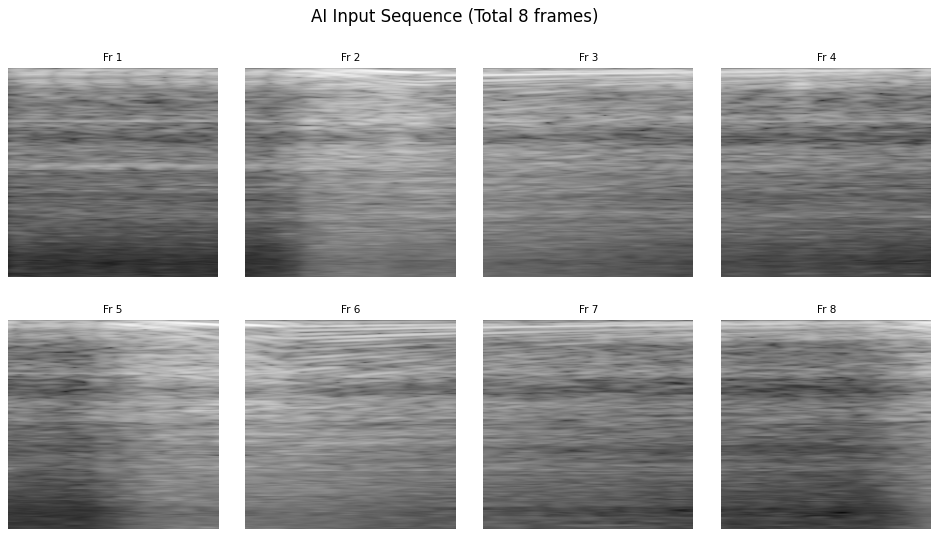

Sample rate: 44100 Hz
anomaly_frames.shape: (3, 224, 1801)


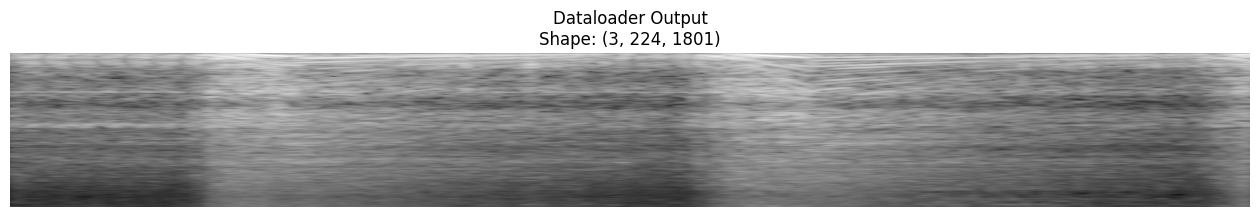

In [6]:
if False:
    anomaly_video_path = files[i]
    
print('anomaly_video_path:',anomaly_video_path)
if True:
    anomaly_frames = video_to_spectrogram_sequence(anomaly_video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length)
    view_spectgram(anomaly_frames,num_frames)

anomaly_frames = video_to_a_spectrogram(anomaly_video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length)
view_spectgram(anomaly_frames,num_frames,one_frame=True)
i+=1

In [7]:
anomaly_video_path = "datasets/bike/normal/HGUwKAq1kxk_trim3.mp4"
IMG_PATH = 'datasets/bike/normal/'
import glob

#files = sorted(glob.glob(IMG_PATH+"*"))
files = glob.glob(IMG_PATH+"*")
i=0


anomaly_video_path: datasets/bike/normal/HGUwKAq1kxk_trim3.mp4
Sample rate: 44100 Hz
step: 224
anomaly_frames.shape: (8, 3, 224, 224)


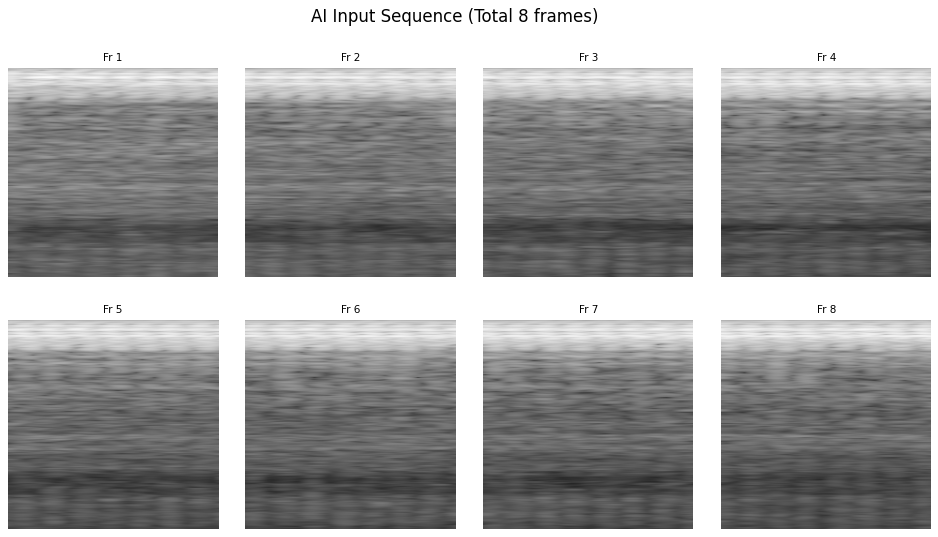

Sample rate: 44100 Hz
anomaly_frames.shape: (3, 224, 1801)


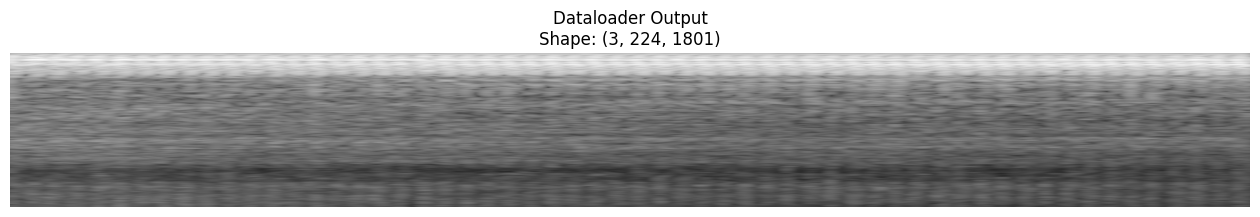

In [8]:
if False:
    anomaly_video_path = files[i]
    
print('anomaly_video_path:',anomaly_video_path)
if True:
    anomaly_frames = video_to_spectrogram_sequence(anomaly_video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length)
    view_spectgram(anomaly_frames,num_frames)

anomaly_frames = video_to_a_spectrogram(anomaly_video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length)
view_spectgram(anomaly_frames,num_frames,one_frame=True)
i+=1